## 习题 1-3
载入 **Yale B 人脸数据库**，先使用标准 `svd` 命令计算其经济型 SVD。

然后再使用 **method of snapshots（快照法）** 计算 SVD。

要求：
1. 在对数坐标下比较两种方法得到的奇异值谱；
2. 比较前 10 个左奇异向量（记得将其 reshape 成人脸图像的形状）；
3. 再比较谱中更靠后的若干奇异向量；
4. 解释观察到的现象。

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.io

In [2]:
mat_contents = scipy.io.loadmat('../../DATA/allfaces.mat')

In [9]:
faces = mat_contents['faces']
m = int(mat_contents['m'])
n = int(mat_contents['n'])
nfaces = np.array(mat_contents['nfaces'])

/var/folders/t9/n3zhf08n4cv_ns10b375thxr0000gn/T/ipykernel_8459/2652126350.py:2: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  m = int(mat_contents['m'])
/var/folders/t9/n3zhf08n4cv_ns10b375thxr0000gn/T/ipykernel_8459/2652126350.py:3: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  n = int(mat_contents['n'])


Task1: 载入 **Yale B 人脸数据库**，先使用标准 `svd` 命令计算其经济型 SVD。

In [19]:
X = faces.astype(np.float64)

In [20]:
U, Sigma, V_T = np.linalg.svd(X, full_matrices=False)

Task2: 使用 **method of snapshots（快照法）** 计算 SVD。
1.	先不直接对 X 做 SVD；
2. 而是先构造一个更小的对称矩阵
$G = X^\top X$;
3.	对 G 做特征值分解：
$X^\top X = V \Lambda V^\top$;
4.	然后利用
$\Lambda = \Sigma^2$
得到奇异值
$\sigma_i = \sqrt{\lambda_i}$;
5.	再由
$U = X V \Sigma^{-1}$

In [21]:
# 构造更小的对称矩阵G
G = X.T @ X

In [47]:
# 对G 做特征分解
eigvals_G, eigvecs_G = np.linalg.eigh(G)
idx = np.argsort(eigvals_G)[::-1]
eigvals_G = eigvals_G[idx]
eigvecs_G = eigvecs_G[:, idx]

In [48]:
# 得到奇异值 Sigma_G
Sigma_G = np.diag(np.sqrt(eigvals_G))

In [49]:
# 最后计算U
U_G = X @ eigvecs_G @ np.linalg.inv(Sigma_G)

Task3: 在对数坐标下比较两种方法得到的奇异值谱

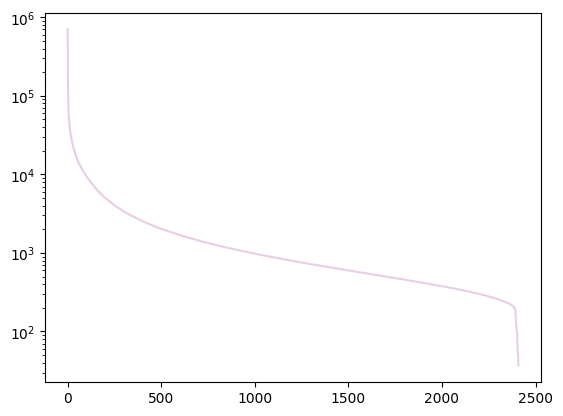

In [50]:
plt.semilogy(Sigma,color = 'blue',alpha = 0.1,label='SVD')
plt.semilogy(np.diag(Sigma_G),color = 'red',alpha = 0.1, label='GOS')
plt.show()

Task4: 比较前 10 个左奇异向量（记得将其 reshape 成人脸图像的形状）；

In [52]:
U_trun = U[:,:10]
U_G_trun = U_G[:,:10]

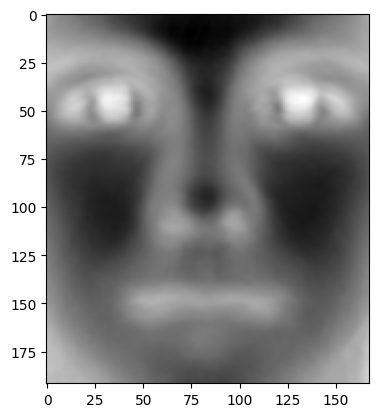

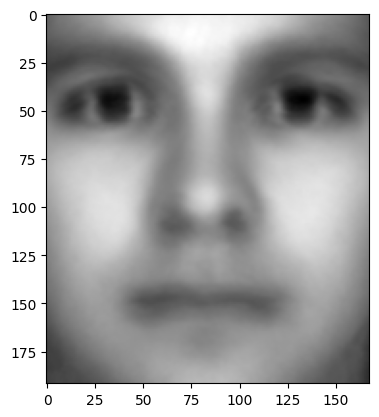

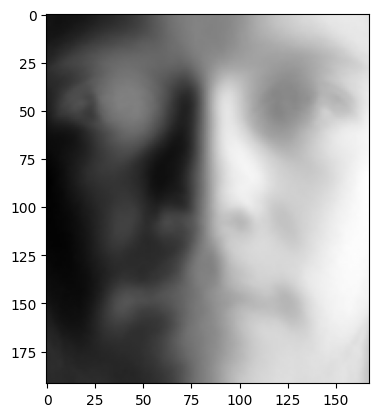

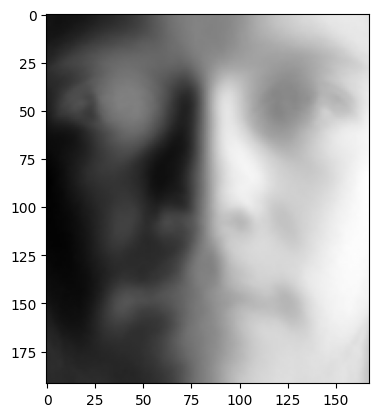

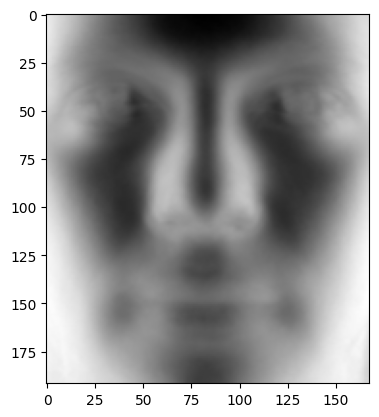

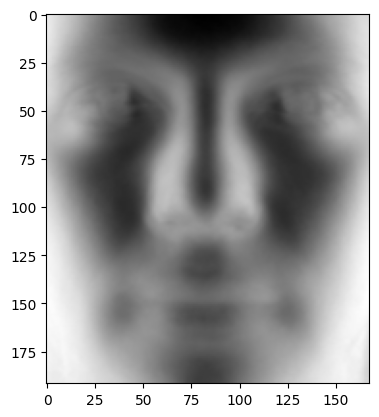

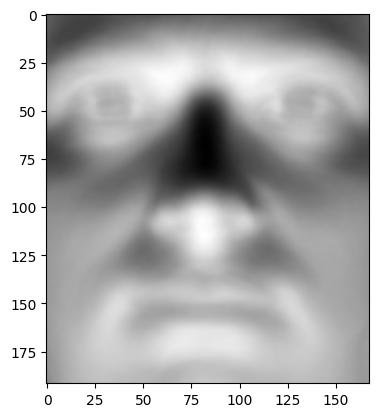

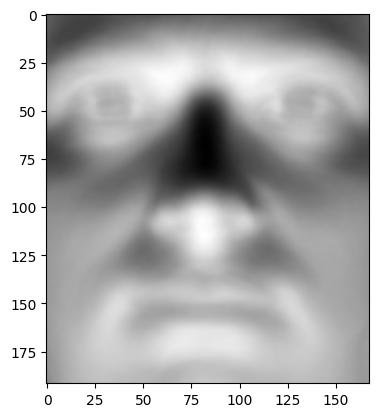

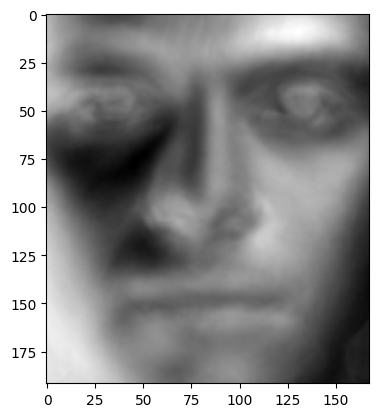

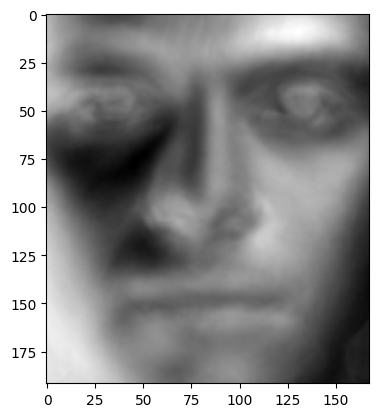

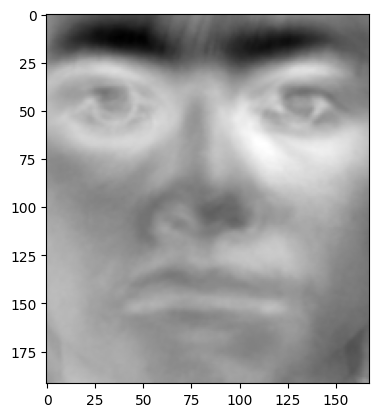

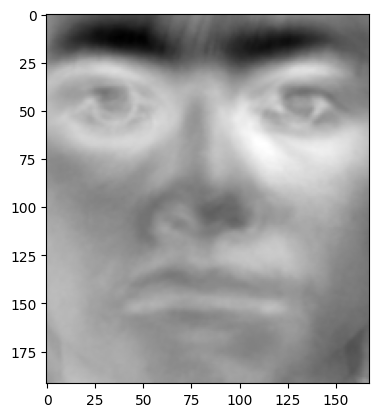

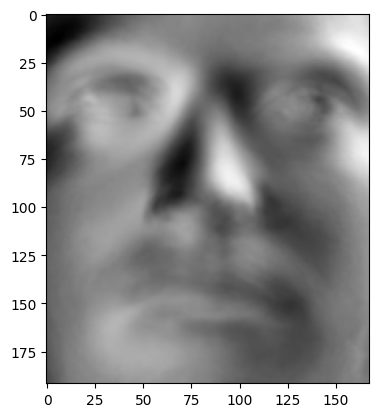

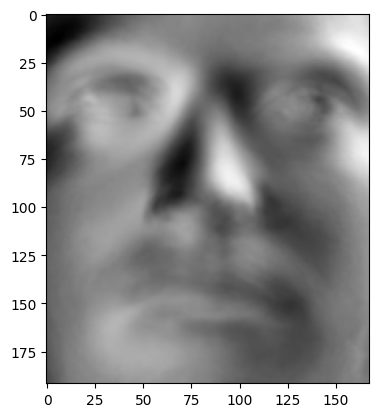

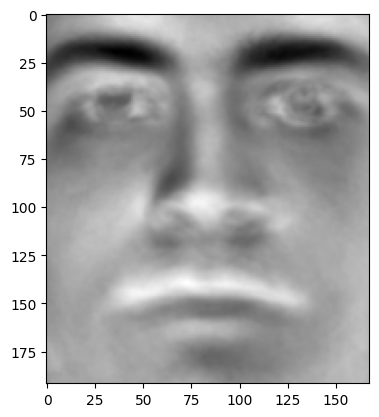

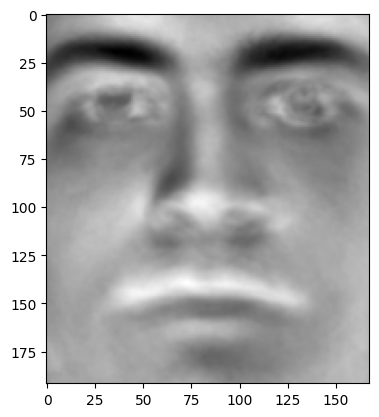

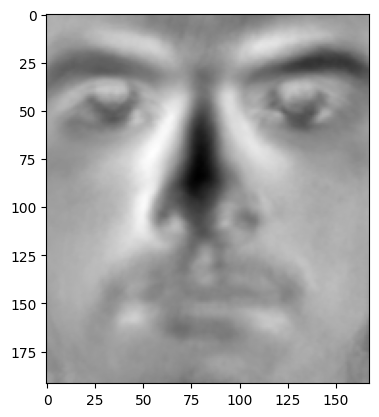

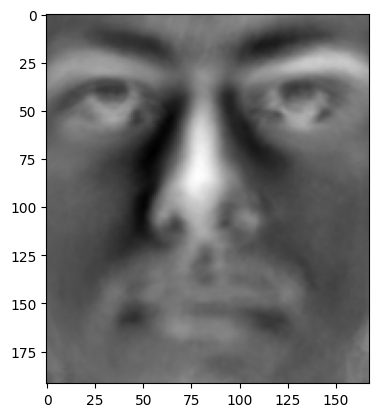

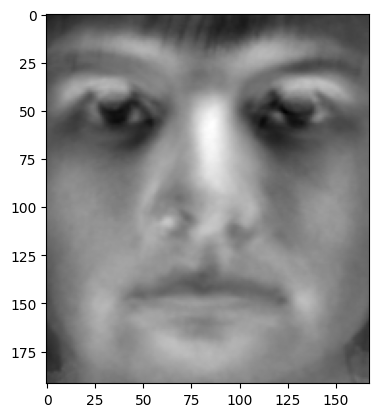

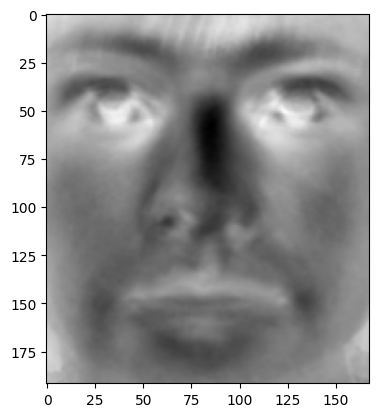

In [53]:
for j in range(10):
    plt.imshow(U_trun[:,j].reshape(m,n).T,cmap='gray')
    plt.show()
    plt.imshow(U_G_trun[:,j].reshape(m,n).T,cmap='gray')
    plt.show()


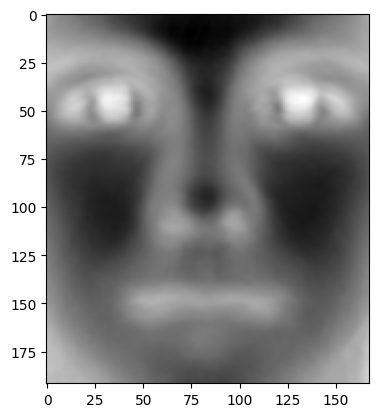

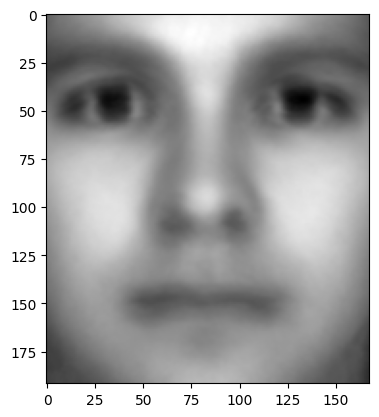

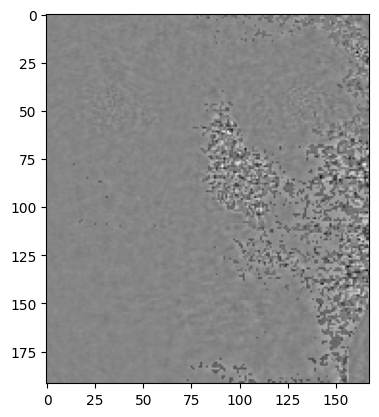

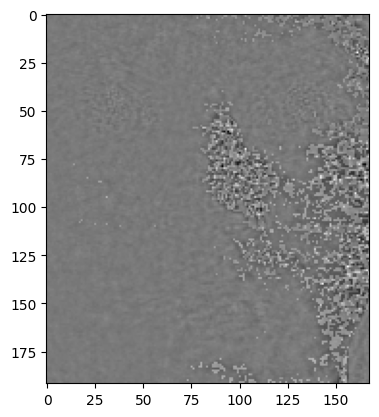

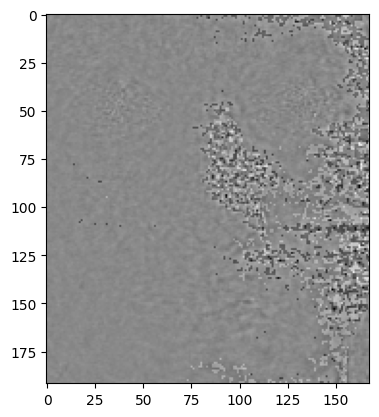

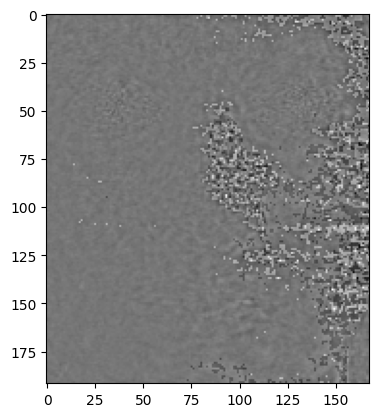

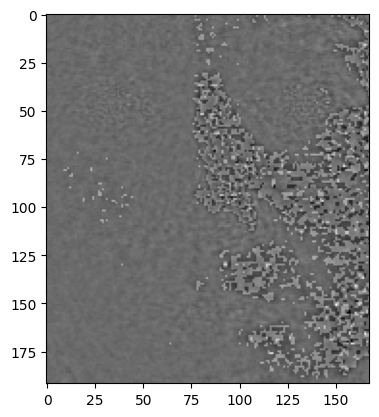

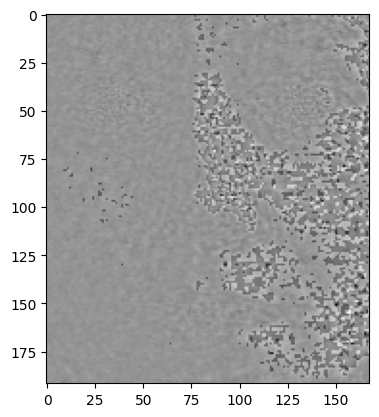

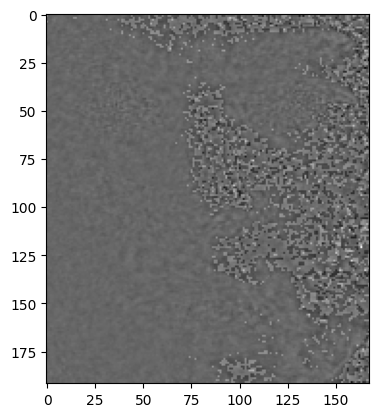

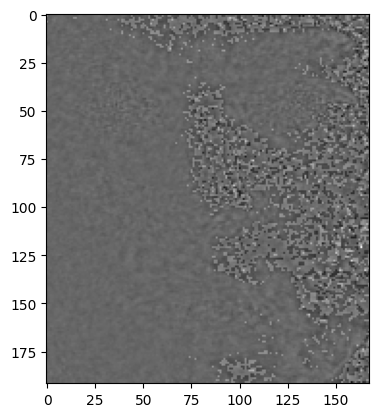

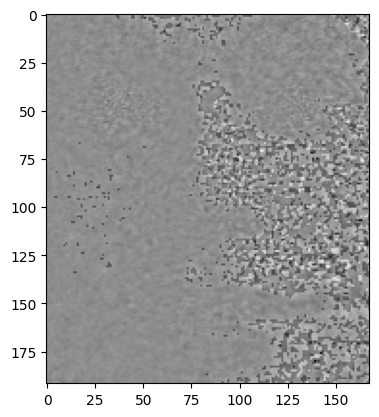

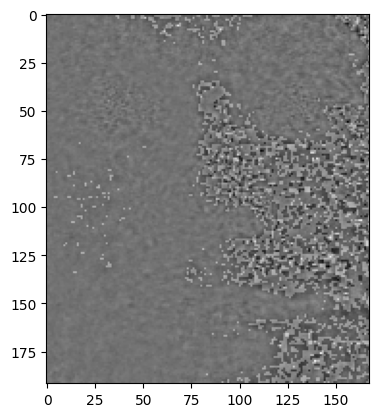

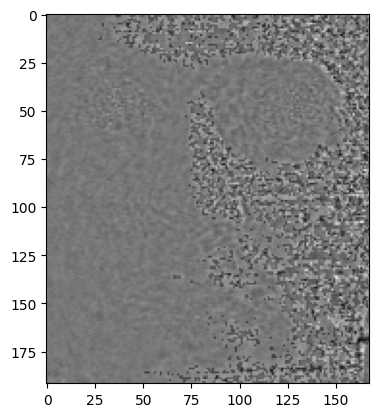

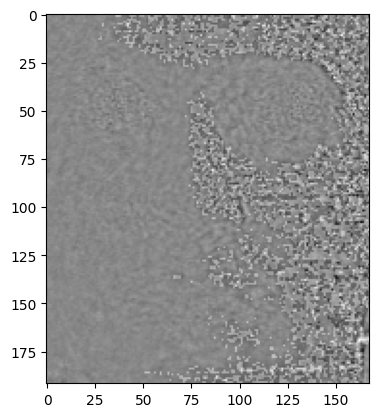

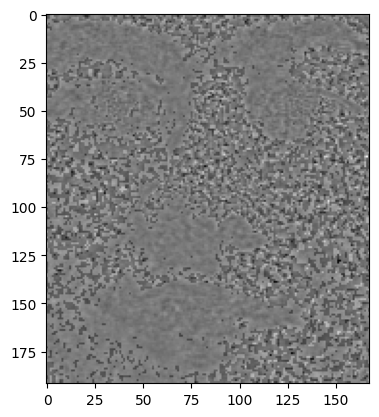

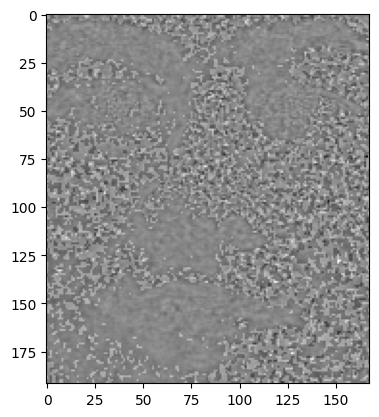

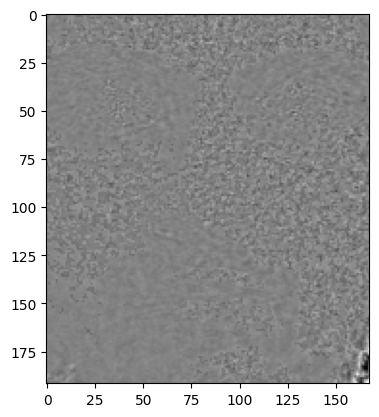

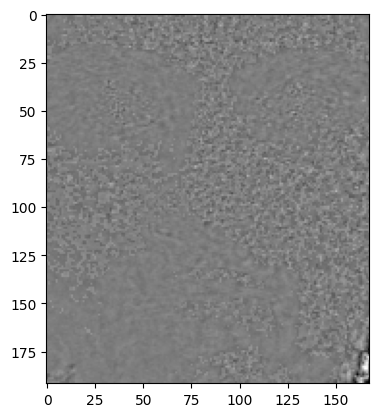

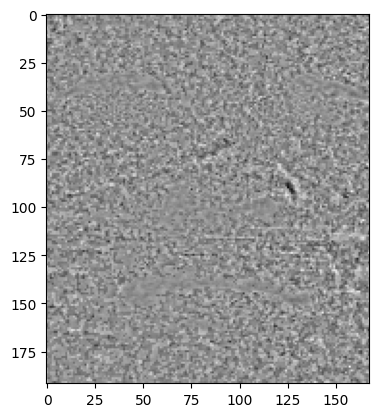

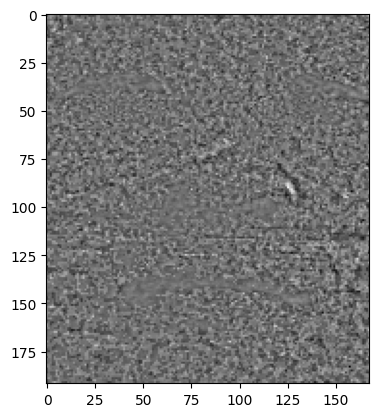

In [54]:
for j in range(10):
    plt.imshow(U[:,-j].reshape(m,n).T,cmap='gray')
    plt.show()
    plt.imshow(U_G[:,-j].reshape(m,n).T,cmap='gray')
    plt.show()
